<a href="https://colab.research.google.com/github/25WH1A05AT/NASSCOM/blob/main/WEEK%203/U6_Probability_Statistics_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [3]:
import numpy as np

flips = np.random.randint(0, 2, size=(100_000, 2))  # 100k pairs of flips
heads = flips.sum(axis=1)  # number of heads in each pair: 0, 1 or 2

# 1. P(both heads) -> heads == 2
p_both_heads = np.mean(heads == 2)
print("P(both heads):", p_both_heads)

# 2. P(at least one head) -> heads >= 1
p_at_least_one = np.mean(heads >= 1)
print("P(at least one head):", p_at_least_one)

# 3. P(0) + P(1) + P(2) should sum to 1
p_0 = np.mean(heads == 0)
p_1 = np.mean(heads == 1)
p_2 = np.mean(heads == 2)

total = p_0 + p_1 + p_2
print("P(0) + P(1) + P(2):", total)

P(both heads): 0.24984
P(at least one head): 0.7494
P(0) + P(1) + P(2): 1.0


In [4]:
import numpy as np

rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [7]:
#LAB EXERCISE2
import numpy as np

rolls = np.random.randint(1, 7, size=100_000)

less_than_4 = rolls[rolls < 4]
p_odd_given_less_4 = (less_than_4 % 2 == 1).mean()
print("P(odd | roll < 4) ~", round(p_odd_given_less_4, 3))

p_less_than_4 = (rolls < 4).mean()
print("P(roll < 4) ~", round(p_less_than_4, 3))

p_odd = (rolls % 2 == 1).mean()
print("P(odd) ~", round(p_odd, 3))
print("Independent?", np.isclose(p_odd_given_less_4, p_odd))

P(odd | roll < 4) ~ 0.666
P(roll < 4) ~ 0.501
P(odd) ~ 0.5
Independent? False


In [8]:
# LAB EXPERIMENT 3

p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham = 0.05
p_ham = 1 - p_spam

p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)

p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("Prior P(spam):", p_spam)
print("Likelihood P(free | spam):", p_free_given_spam)
print("False-positive rate P(free | ham):", p_free_given_ham)
print("P(free):", p_free)
print("P(spam | free):", p_spam_given_free)
print("P(spam | free) percentage:", p_spam_given_free * 100, "%")

Prior P(spam): 0.2
Likelihood P(free | spam): 0.6
False-positive rate P(free | ham): 0.05
P(free): 0.16
P(spam | free): 0.75
P(spam | free) percentage: 75.0 %


Sample mean: 1.9952


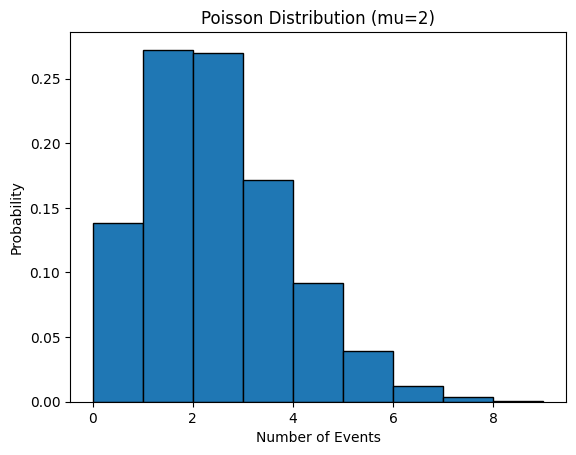

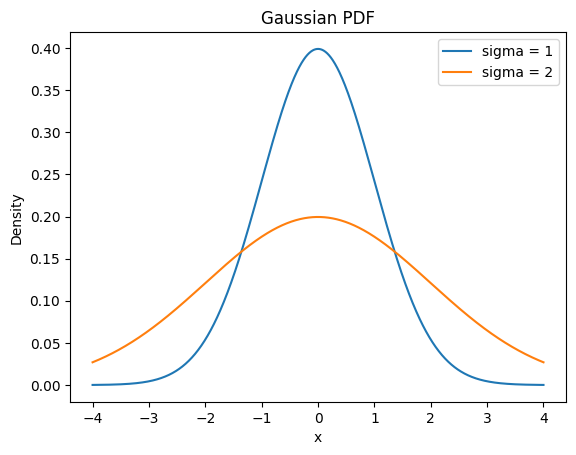

In [10]:
# LAB EXPERIMENT 4

import numpy as np
import matplotlib.pyplot as plt

# 1. Poisson(mu=2) samples + mean
samples = np.random.poisson(lam=2, size=10000)
print("Sample mean:", samples.mean())

# 2. Histogram of the samples
plt.hist(samples, bins=range(samples.max() + 2), density=True, edgecolor="black")
plt.xlabel("Number of Events")
plt.ylabel("Probability")
plt.title("Poisson Distribution (mu=2)")
plt.show()

# 3. Gaussian PDF for two sigmas on one plot
x = np.linspace(-4, 4, 1000)
mu = 0
sigma1 = 1
sigma2 = 2

pdf1 = (1 / (sigma1 * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma1 ** 2))
pdf2 = (1 / (sigma2 * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma2 ** 2))

plt.plot(x, pdf1, label="sigma = 1")
plt.plot(x, pdf2, label="sigma = 2")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Gaussian PDF")
plt.legend()
plt.show()

In [11]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')


Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [12]:
# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')



D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [13]:
# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')


0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [14]:
# LAB EXPERIMENT 5

import numpy as np

p4 = np.array([1/4] * 4)
p6 = np.array([1/6] * 6)

entropy_4 = -np.sum(p4 * np.log2(p4))
entropy_6 = -np.sum(p6 * np.log2(p6))

print("Entropy of 4-sided die:", entropy_4, "bits")
print("Entropy of 6-sided die:", entropy_6, "bits")

print("More uncertain:", "6-sided die")

P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

kl_divergence = np.sum(P * np.log2(P / Q))

print("KL Divergence D(P || Q):", kl_divergence)

most_informative = "Petal length"
least_informative = "Sepal width"

print("Most informative feature:", most_informative)
print("Least informative feature:", least_informative)

Entropy of 4-sided die: 2.0 bits
Entropy of 6-sided die: 2.584962500721156 bits
More uncertain: 6-sided die
KL Divergence D(P || Q): 0.1187091007693073
Most informative feature: Petal length
Least informative feature: Sepal width
